- basics.ipynb
- 
- Section 1: Load dataset
- Section 2: Create labeled and unlabeled split
- Section 3: Train supervised baseline
- Section 4: Apply Self-Training
- Section 5: Apply Label Propagation
- Section 6: Apply Mean Teacher
- Section 7: Apply FixMatch
- Section 8: Compare results
- 

In [3]:
import torch 
import torchvision 
import torchvision.transforms as transforms
import numpy as np 
import matplotlib.pyplot as plt

In [9]:
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

print('train size', len(train_dataset))
print('test size', len(test_dataset))

100%|██████████| 26.4M/26.4M [00:16<00:00, 1.56MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 72.8kB/s]
100%|██████████| 4.42M/4.42M [01:44<00:00, 42.2kB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 2.79MB/s]

train size 60000
test size 10000


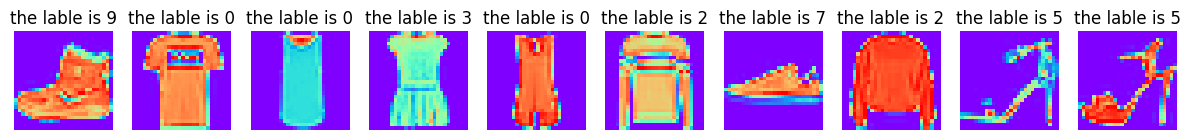

In [12]:
def show_images(dataset,num=10):
    fig,axes = plt.subplots(1,num,figsize=(15,6))

    for i in range(num):
        image,lable = dataset[i]
        axes[i].imshow(image.squeeze(),cmap='rainbow')
        axes[i].set_title(f"the lable is {lable}")
        axes[i].axis('off')
    plt.show()

show_images(train_dataset,10)

## split the labeld and unlabeld data 


In [18]:
num_labeled = int(0.1 * len(train_dataset))
num_unlabeled = len(train_dataset) - num_labeled

indices = np.random.permutation(len(train_dataset))

labeled_indices = indices[:num_labeled]
unlabeled_indices = indices[num_labeled:]

print("Labeled samples:", len(labeled_indices))
print("Unlabeled samples:", len(unlabeled_indices))


Labeled samples: 6000
Unlabeled samples: 54000


In [19]:
from torch.utils.data import Subset, DataLoader

labeled_dataset = Subset(train_dataset, labeled_indices)

labeled_loader = DataLoader(
    labeled_dataset,
    batch_size=64,
    shuffle=True,
    
)

unlabeled_dataset = Subset(train_dataset, unlabeled_indices)

unlabeled_loader = DataLoader(
    unlabeled_dataset,
    batch_size=64,
    shuffle=True,
   
)

len(labeled_loader)

94

In [20]:
import torch.nn as nn
import torch.nn.functional as F

class SimpleNN(nn.Module):
    
    def __init__(self):
        super().__init__()
        
        self.fc1 = nn.Linear(28*28, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)
        
    def forward(self, x):
        
        x = x.view(-1, 28*28)
        
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        
        return x

model = SimpleNN()

print(model)


SimpleNN(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
)


In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

criterion = nn.CrossEntropyLoss()


In [22]:
def train(model, loader, epochs=5):
    
    model.train()
    
    for epoch in range(epochs):
        
        total_loss = 0
        
        for images, labels in loader:
            
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            
            outputs = model(images)
            
            loss = criterion(outputs, labels)
            
            loss.backward()
            
            optimizer.step()
            
            total_loss += loss.item()
        
        print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

train(model, labeled_loader, epochs=5)


Epoch 1, Loss: 105.4701
Epoch 2, Loss: 60.3449
Epoch 3, Loss: 50.1943
Epoch 4, Loss: 45.4811
Epoch 5, Loss: 42.1056


In [25]:
def test(model, loader):
    
    model.eval()
    
    correct = 0
    total = 0
    
    with torch.no_grad():
        
        for images, labels in loader:
            
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            
            _, predicted = torch.max(outputs, 1)
            
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    accuracy = 100 * correct / total
    
    print(f"Accuracy: {accuracy:.2f}%")

test(model, unlabeled_loader)


Accuracy: 82.50%
